<h1><font color="blue">판다스 데이터 분석</font></h1>

<h2><font color="red">임시 데이터 만들기</font></h2>

<h4><font color="green">데이터 저장하기</font></h4>

<h6><font color="BlueViolet">가중치를 적용한 데이터 만들기</font></h6>

In [35]:
import pandas as pd
import numpy as np


x = np.array(['빨강', '파랑', '노랑', '녹색'])

weights = [0.1, 0.3, 0.2, 0.4]  # 각 원소에 대한 가중치
sample_size = 100  # 추출할 데이터의 개수

sample = np.random.choice(x, size=sample_size, p=weights, replace=True)
myseries = pd.Series(sample)
myseries.value_counts().to_frame().T

,녹색,파랑,노랑,빨강
count,40,24,23,13


<h6><font color="BlueViolet">임시 데이터 기초</font></h6>

In [36]:
import random
import pandas as pd
from faker import Faker

fake = Faker('ko_KR')

In [37]:
totaldata = []
columns01 = ('아이디', '이름', '성별', '생일', '결혼', '종교', '소득', '주소', '전화번호', '이메일')
myencoding = 'CP949' # 인코딩 문자열
item_size = 10000 # 생성할 데이터 개수

In [38]:
for idx in range(item_size):
    sublist = []
    sublist.append(fake.user_name()) # 아이디
    sublist.append(fake.name()) # 이름
    sublist.append(fake.pyint(min_value=1, max_value=4)) # 성별(1과 3은 남자, 2와 4는 여자)
    sublist.append(fake.pyint(min_value=1950, max_value=2010)) # 생일
    sublist.append(fake.pyint(min_value=1, max_value=4)) # 결혼(1), 이혼(2), 미혼(3), 사별(4)
    sublist.append(fake.pyint(min_value=1, max_value=4)) # 종교(불교(1), 천주교(2), 기독교(3), 기타(4))
    sublist.append(fake.pyint(min_value=100, max_value=1000)) # 소득
    sublist.append(fake.address()) # 주소
    sublist.append(fake.phone_number()) # 전화 번호
    sublist.append(fake.email()) # 이메일
    totaldata.append(sublist)

In [39]:
members = pd.DataFrame(totaldata, columns = columns01)
print('데이터 프레임 내용 확인')
members.head()

데이터 프레임 내용 확인


,아이디,이름,성별,생일,결혼,종교,소득,주소,전화번호,이메일
0,zi,박보람,4,1992,3,3,502,인천광역시 은평구 석촌호수거리,063-149-4959,oi@example.org
1,jeongjai,강재현,1,1984,4,2,357,전라남도 시흥시 잠실1길,063-749-2143,no@example.org
2,gi,이보람,2,1955,1,2,875,대전광역시 관악구 개포21가,042-468-5389,sunja89@example.net
3,yujin60,우유진,1,2005,3,1,186,경상남도 성남시 수정구 서초중앙31길,019-138-3402,eungyeong58@example.org
4,minjibag,김민석,4,1953,3,4,577,세종특별자치시 강서구 백제고분79길 (성훈오김마을),011-369-1518,gimsubin@example.net


In [40]:
job = np.array(['파이썬 개발자', '데이터베이스 개발자', '웹 디자이너', \
                '머신 러닝 개발자', '자바 개발자', '데이터 분석가'])

weights = [0.25, 0.15, 0.15, 0.1, 0.25, 0.1]  # 각 원소에 대한 가중치
sample_size = item_size # 추출할 데이터의 개수

np.random.seed(1234)
sample = np.random.choice(job, size=sample_size, p=weights, replace=True)
myseries = pd.Series(sample)
myseries.value_counts().to_frame().T

,파이썬 개발자,자바 개발자,웹 디자이너,데이터베이스 개발자,머신 러닝 개발자,데이터 분석가
count,2525,2509,1493,1440,1025,1008


In [41]:
members['직업'] = myseries
members.head()

,아이디,이름,성별,생일,결혼,종교,소득,주소,전화번호,이메일,직업
0,zi,박보람,4,1992,3,3,502,인천광역시 은평구 석촌호수거리,063-149-4959,oi@example.org,파이썬 개발자
1,jeongjai,강재현,1,1984,4,2,357,전라남도 시흥시 잠실1길,063-749-2143,no@example.org,머신 러닝 개발자
2,gi,이보람,2,1955,1,2,875,대전광역시 관악구 개포21가,042-468-5389,sunja89@example.net,웹 디자이너
3,yujin60,우유진,1,2005,3,1,186,경상남도 성남시 수정구 서초중앙31길,019-138-3402,eungyeong58@example.org,자바 개발자
4,minjibag,김민석,4,1953,3,4,577,세종특별자치시 강서구 백제고분79길 (성훈오김마을),011-369-1518,gimsubin@example.net,자바 개발자


In [42]:
filename = './../data/member_data.csv'
members.to_csv(filename , encoding=myencoding, mode='w', index=False)

<h4><font color="green">데이터 불러오기</font></h4>

<h6><font color="BlueViolet">read_csv() 함수</font></h6>

In [43]:
members = pd.read_csv(filename, index_col='아이디', encoding=myencoding)
print(type(members))
members.head()

<class 'pandas.core.frame.DataFrame'>


,이름,성별,생일,결혼,종교,소득,주소,전화번호,이메일,직업
아이디,,,,,,,,,,
zi,박보람,4,1992,3,3,502,인천광역시 은평구 석촌호수거리,063-149-4959,oi@example.org,파이썬 개발자
jeongjai,강재현,1,1984,4,2,357,전라남도 시흥시 잠실1길,063-749-2143,no@example.org,머신 러닝 개발자
gi,이보람,2,1955,1,2,875,대전광역시 관악구 개포21가,042-468-5389,sunja89@example.net,웹 디자이너
yujin60,우유진,1,2005,3,1,186,경상남도 성남시 수정구 서초중앙31길,019-138-3402,eungyeong58@example.org,자바 개발자
minjibag,김민석,4,1953,3,4,577,세종특별자치시 강서구 백제고분79길 (성훈오김마을),011-369-1518,gimsubin@example.net,자바 개발자


In [44]:
print('열 색인 정보 확인')
print(members.columns)

열 색인 정보 확인
Index(['이름', '성별', '생일', '결혼', '종교', '소득', '주소', '전화번호', '이메일', '직업'], dtype='object')


In [45]:
# 데이터 전처리
members.loc[members['성별'] == 1 , ['성별']] = '남자'
members.loc[members['성별'] == 2 , ['성별']] = '여자'
members.loc[members['성별'] == 3 , ['성별']] = '남자'
members.loc[members['성별'] == 4 , ['성별']] = '여자'

C:\Users\ugcad\AppData\Local\Temp\ipykernel_8896\343319712.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '남자' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  members.loc[members['성별'] == 1 , ['성별']] = '남자'


In [46]:
# 나이 컬럼은 존재하지 않으므로 생일 컬럼을 이용하여 산술 연산합니다.
thisyear = 2023
members['나이'] = thisyear - members['생일'] + 1

In [47]:
# 결혼(1), 이혼(2), 미혼(3), 사별(4)
def setMarriage(data):
    if data == 1 :
        return '결혼'
    elif data == 2 :
        return '이혼'
    elif data == 3 :
        return '미혼'        
    else :
        return '사별'
# def setMarriage(data):

In [48]:
members['결혼'] = members['결혼'].apply(setMarriage)

In [49]:
# 종교(불교(1), 천주교(2), 기독교(3), 기타(4))
def setReligion(data):
    if data == 1 :
        return '불교'
    elif data == 2 :
        return '천주교'
    elif data == 3 :
        return '기독교'        
    else :
        return '기타'
# def setReligion(data):  

In [50]:
members['종교숫자'] = members['종교'] 
members['종교'] = members['종교숫자'].apply(setReligion)

In [51]:
members['나이'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
나이,10000.0,43.9583,17.554064,14.0,29.0,44.0,59.0,74.0


In [52]:
# 청년_young(30세 미만), 중년_middle(30세 이상), 노년_old(60세 이상)
def newAge(data):
    if data < 30:
        return '청년'
    elif data >= 30 and data < 60:
        return '중년'
    else :
        return '노년'
# def newAge(data)

In [53]:
members['연령대'] = members['나이'].apply(newAge)
members[['나이', '연령대']].head()

,나이,연령대
아이디,,
zi,32,중년
jeongjai,40,중년
gi,69,노년
yujin60,19,청년
minjibag,71,노년


In [54]:
members.head()

,이름,성별,생일,결혼,종교,소득,주소,전화번호,이메일,직업,나이,종교숫자,연령대
아이디,,,,,,,,,,,,,
zi,박보람,여자,1992,미혼,기독교,502,인천광역시 은평구 석촌호수거리,063-149-4959,oi@example.org,파이썬 개발자,32,3,중년
jeongjai,강재현,남자,1984,사별,천주교,357,전라남도 시흥시 잠실1길,063-749-2143,no@example.org,머신 러닝 개발자,40,2,중년
gi,이보람,여자,1955,결혼,천주교,875,대전광역시 관악구 개포21가,042-468-5389,sunja89@example.net,웹 디자이너,69,2,노년
yujin60,우유진,남자,2005,미혼,불교,186,경상남도 성남시 수정구 서초중앙31길,019-138-3402,eungyeong58@example.org,자바 개발자,19,1,청년
minjibag,김민석,여자,1953,미혼,기타,577,세종특별자치시 강서구 백제고분79길 (성훈오김마을),011-369-1518,gimsubin@example.net,자바 개발자,71,4,노년


In [55]:
members.to_csv('./../data/membersClean.csv', index=False, encoding='cp949')

<h6><font color="BlueViolet">메소드 개수 파악하기</font></h6>

In [56]:
members.columns

Index(['이름', '성별', '생일', '결혼', '종교', '소득', '주소', '전화번호', '이메일', '직업', '나이',
       '종교숫자', '연령대'],
      dtype='object')

In [57]:
members.describe().T

,count,mean,std,min,25%,50%,75%,max
생일,10000.0,1980.0417,17.554064,1950.0,1965.0,1980.0,1995.0,2010.0
소득,10000.0,546.1170,259.824136,100.0,321.0,546.5,770.0,1000.0
나이,10000.0,43.9583,17.554064,14.0,29.0,44.0,59.0,74.0
종교숫자,10000.0,2.4692,1.117666,1.0,1.0,2.0,3.0,4.0


<h6><font color="BlueViolet">메소드 확인하기</font></h6>

In [58]:
members['종교'].unique()

array(['기독교', '천주교', '불교', '기타'], dtype=object)

In [59]:
members['결혼'].unique()

array(['미혼', '사별', '결혼', '이혼'], dtype=object)

In [60]:
members['직업'].unique()

array(['파이썬 개발자', '머신 러닝 개발자', '웹 디자이너', '자바 개발자', '데이터베이스 개발자',
       '데이터 분석가'], dtype=object)

In [61]:
members['연령대'].unique()

array(['중년', '노년', '청년'], dtype=object)

<h6><font color="BlueViolet">Series 속성</font></h6>

In [62]:
print('결혼 빈도')
result = members.groupby('결혼')['결혼'].count()
result.to_frame().T

결혼 빈도


결혼,결혼,미혼,사별,이혼
결혼,2528,2498,2447,2527


<h6><font color="BlueViolet">기초 통계량 확인</font></h6>

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic') # 한글 깨짐
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 처리

In [64]:
ORDERING = ['결혼', '이혼', '미혼', '사별'] # 그려질 순서

<Axes: title={'center': '결혼 빈도'}, xlabel='결혼', ylabel='count'>

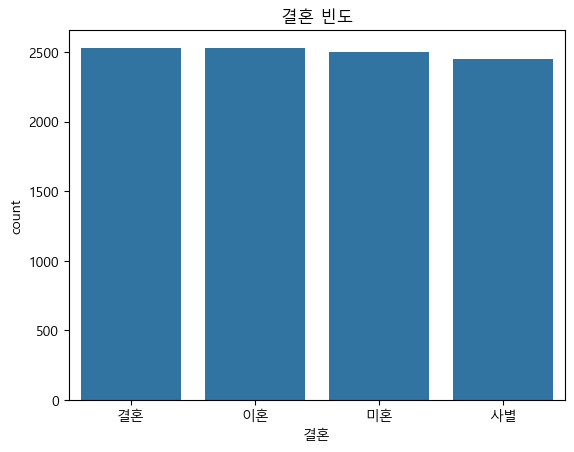

In [65]:
plt.figure()
plt.title('결혼 빈도')
sns.countplot(x='결혼', data=members, order=ORDERING)

<h6><font color="BlueViolet">누락된 데이터 확인</font></h6>

In [66]:
print('결혼 vs 종교 빈도')
result = members.groupby(['결혼', '종교'])['결혼'].count()
result.to_frame()

결혼 vs 종교 빈도


결혼
결혼 종교      
결혼 기독교  602
   기타   605
   불교   629
   천주교  692
미혼 기독교  601
   기타   639
   불교   629
   천주교  629
사별 기독교  588
   기타   558
   불교   648
   천주교  653
이혼 기독교  626
   기타   623
   불교   669
   천주교  609

<Axes: title={'center': '결혼 vs 종교 빈도'}, xlabel='결혼', ylabel='count'>

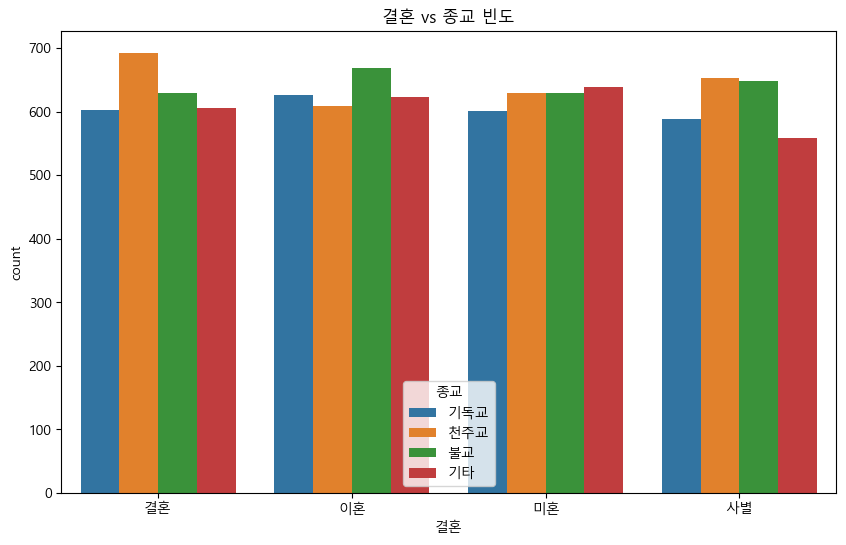

In [70]:
plt.figure(figsize=(10, 6))
plt.title('결혼 vs 종교 빈도')
sns.countplot(x='결혼', hue='종교', data=members, order=ORDERING)

ValueError: Invalid RGBA argument: [(0.0, 0.10980392156862745, 0.4980392156862745), (0.6941176470588235, 0.25098039215686274, 0.050980392156862744), (0.07058823529411765, 0.44313725490196076, 0.10980392156862745)]

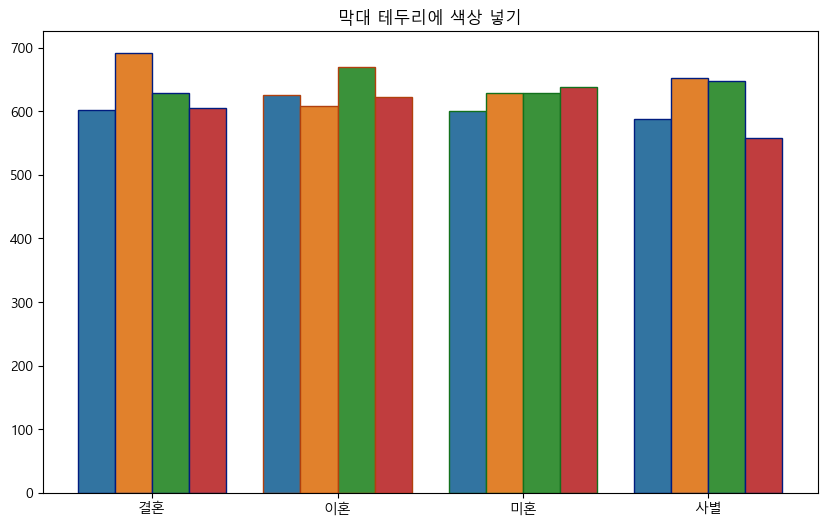

In [72]:
plt.figure(figsize=(10, 6))
plt.title('막대 테두리에 색상 넣기')
sns.countplot(x='결혼', hue='종교', data=members, order=ORDERING, \
              linewidth=1, edgecolor=sns.color_palette("dark", 3))

<h6><font color="BlueViolet">색인 필터링</font></h6>


<Axes: title={'center': '가로 막대로 그리기'}, xlabel='count', ylabel='결혼'>

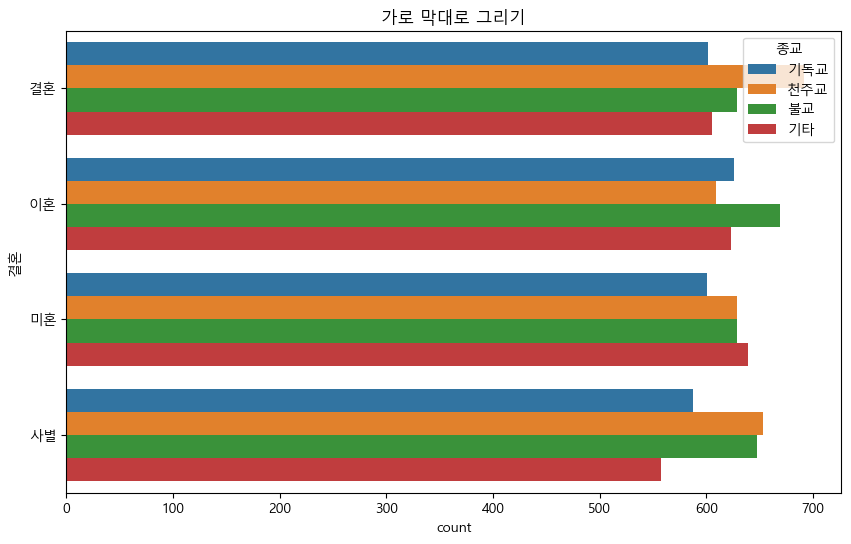

In [73]:
plt.figure(figsize=(10, 6))
plt.title('가로 막대로 그리기')
sns.countplot(y='결혼', hue='종교', data=members, order=ORDERING)

<Axes: title={'center': '색상 팔레트 설정'}, xlabel='결혼', ylabel='count'>

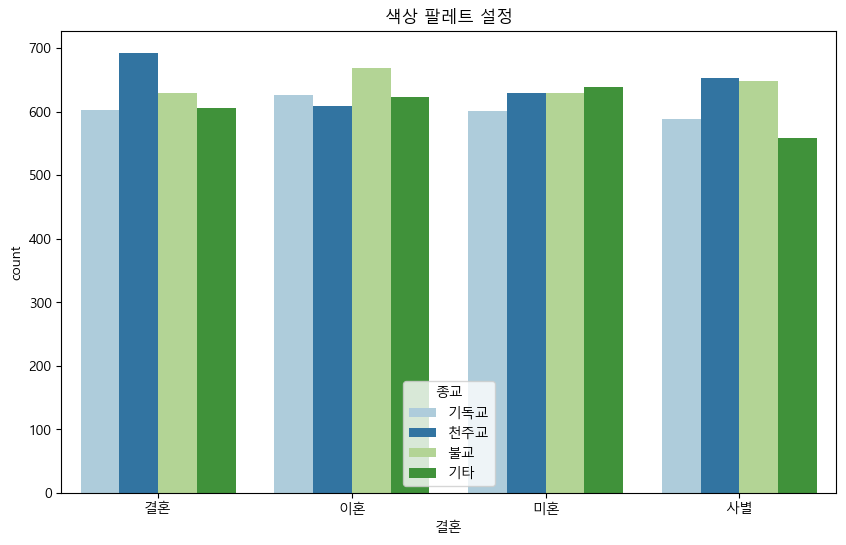

In [74]:
plt.figure(figsize=(10, 6))
plt.title('색상 팔레트 설정')
sns.countplot(x='결혼', hue='종교', palette='Paired', data=members, order=ORDERING)

Text(0.5, 1.0, 'rugplot과 kde')

<Figure size 1000x600 with 0 Axes>

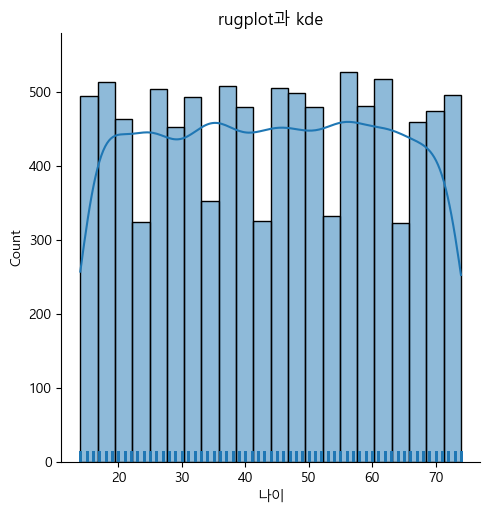

In [75]:
x = members['나이']
plt.figure(figsize=(10, 6))
sns.displot(x, rug=True, kde=True)
plt.title('rugplot과 kde')

<h6><font color="BlueViolet">빈도수 파악하기</font></h6>

Text(0.5, 1.0, '컬러 바꾸기')

<Figure size 1000x600 with 0 Axes>

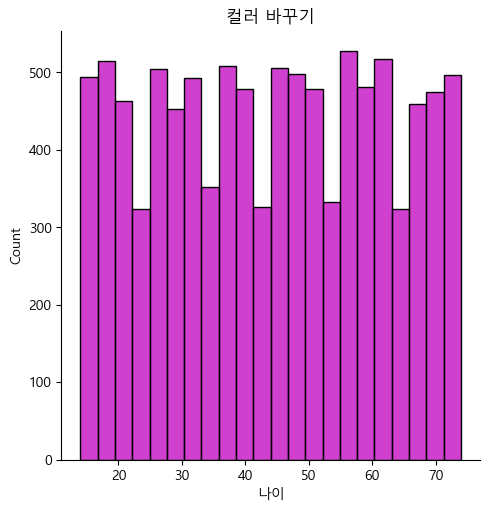

In [76]:
plt.figure(figsize=(10, 6))
sns.displot(x, color="m")
plt.title('컬러 바꾸기')

<h4><font color="green">Series의 메소드 Chaining</font></h4>

In [77]:
pivot = members.pivot_table(index='성별', columns='결혼', values='나이')
print('pivot_table을 이용한 시각화')
pivot

pivot_table을 이용한 시각화


결혼,결혼,미혼,사별,이혼
성별,,,,
남자,44.292590,43.275917,44.244548,44.441153
여자,44.127974,44.306270,43.592433,43.358372


<h6><font color="BlueViolet">히트맵 그리기</font></h6>

<Axes: title={'center': '결혼과 성별에 대한 히트맵'}, xlabel='결혼', ylabel='성별'>

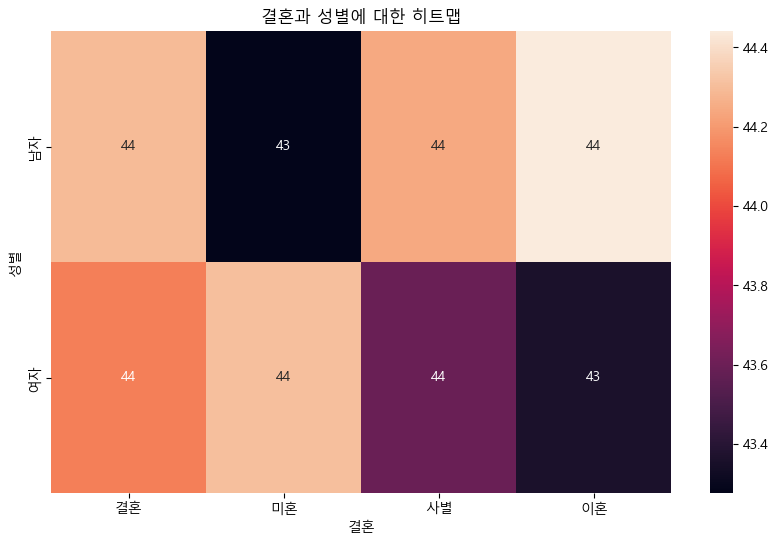

In [78]:
plt.figure(figsize=(10, 6))
plt.title('결혼과 성별에 대한 히트맵')
sns.heatmap(data=pivot, annot=True)

<h6><font color="BlueViolet">상관 관계 시각화</font></h6>

In [79]:
corrdata = members[['생일', '소득', '나이']] 
cor = corrdata.corr(numeric_only  = True)
print('상관 관계 시각화')
cor

상관 관계 시각화


,생일,소득,나이
생일,1.000000,-0.009068,-1.000000
소득,-0.009068,1.000000,0.009068
나이,-1.000000,0.009068,1.000000


<Axes: title={'center': '상관 관계 시각화'}>

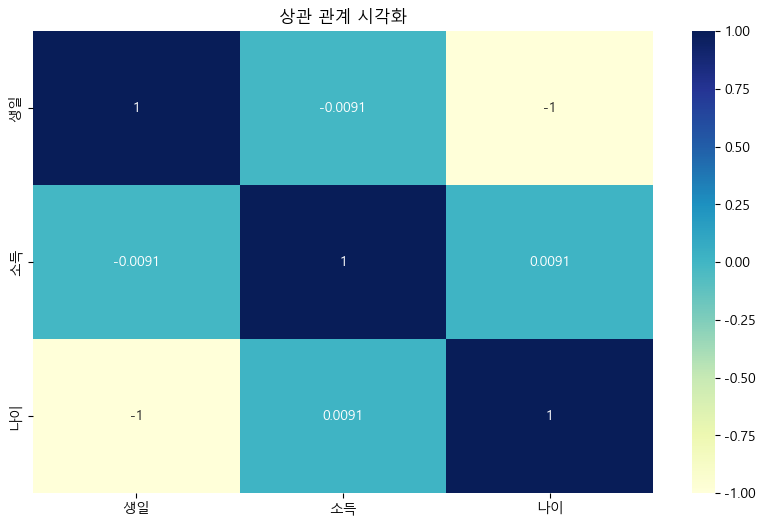

In [80]:
plt.figure(figsize=(10, 6))
plt.title('상관 관계 시각화')
sns.heatmap(data=cor, annot=True, cmap="YlGnBu")

<h6><font color="BlueViolet">pairplot 그리기</font></h6>

<Figure size 640x480 with 0 Axes>

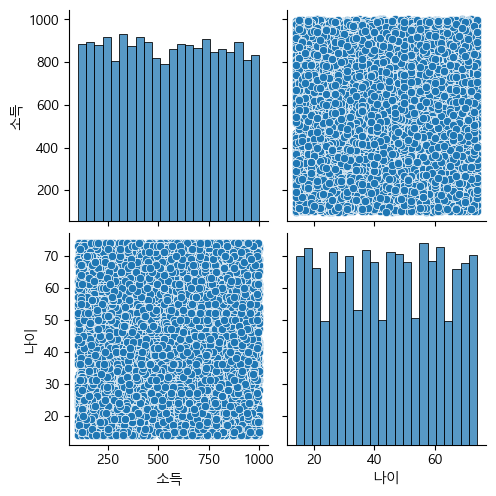

In [81]:
newmembers = members.loc[:, ['소득', '나이', '결혼']]

plt.figure()
sns.pairplot(data=newmembers)

<Figure size 1000x600 with 0 Axes>

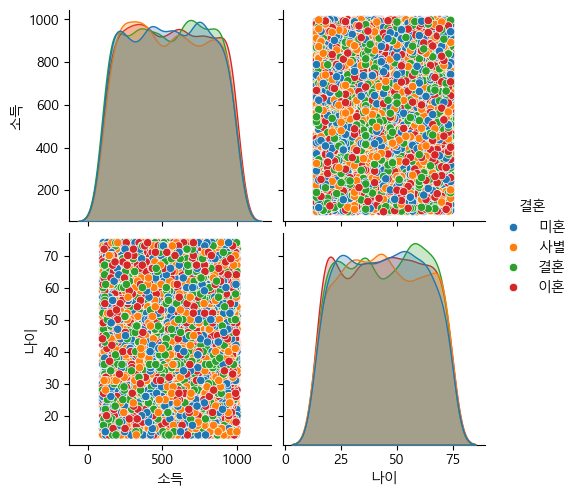

In [82]:
plt.figure(figsize=(10, 6))
sns.pairplot(data=newmembers, hue='결혼')

<Figure size 1000x600 with 0 Axes>

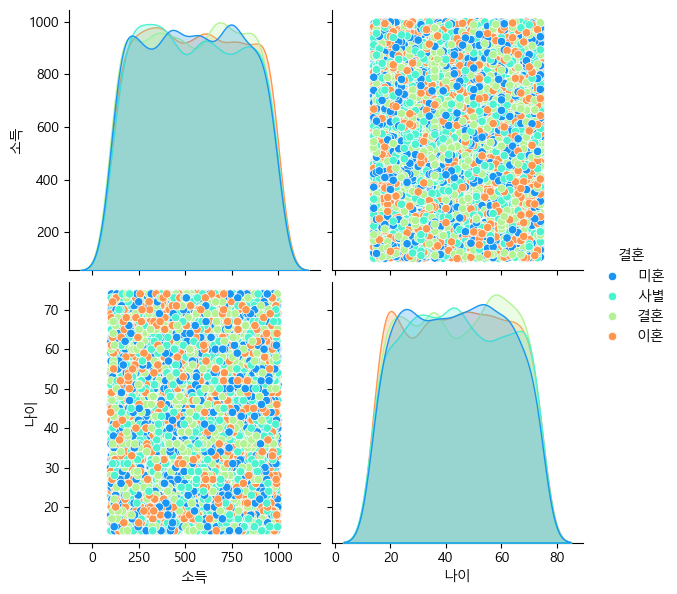

In [83]:
plt.figure(figsize=(10, 6))
sns.pairplot(data=newmembers, hue='결혼', palette="rainbow", height=3,)

In [84]:
print("members['나이'].describe()")
members['나이'].describe().to_frame().T

members['나이'].describe()


,count,mean,std,min,25%,50%,75%,max
나이,10000.0,43.9583,17.554064,14.0,29.0,44.0,59.0,74.0


<h6><font color="BlueViolet">바이올린 그래프 그리기</font></h6>

<Axes: title={'center': '나이에 대한 바이올린 그래프'}, xlabel='나이'>

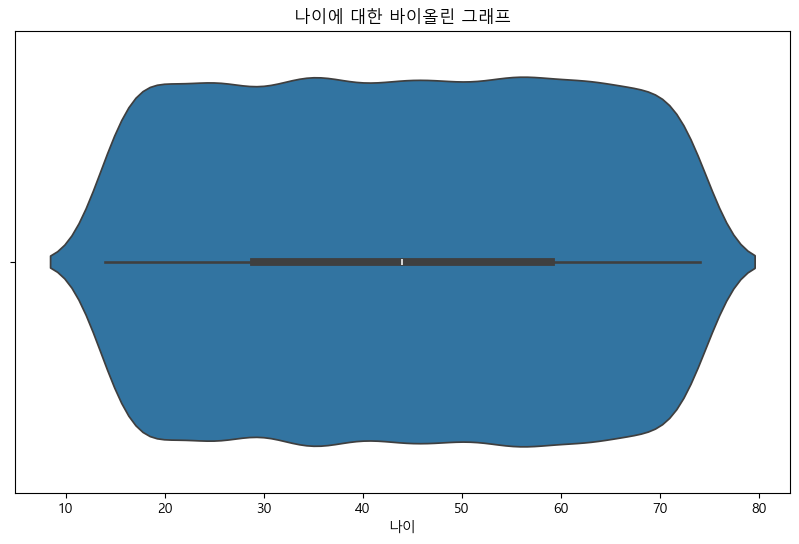

In [85]:
plt.figure(figsize=(10, 6))
plt.title('나이에 대한 바이올린 그래프')
sns.violinplot(x='나이', data=members)

<h6><font color="BlueViolet">list를 사용한 색인 이름 변경</font></h6>

x, y축을 지정해 줌으로써 바이올린을 분할하여 비교 분포를 볼 수 있습니다.


<Axes: title={'center': '비교 분포 확인'}, xlabel='성별', ylabel='나이'>

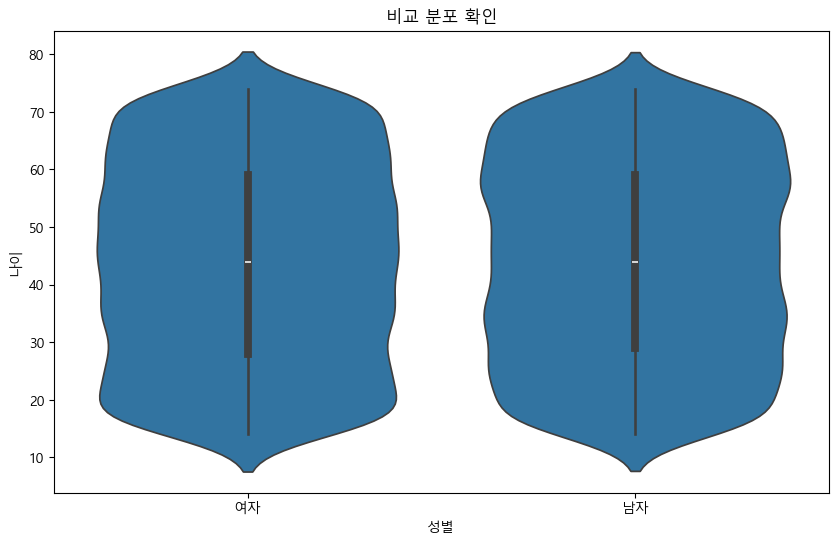

In [86]:
print('x, y축을 지정해 줌으로써 바이올린을 분할하여 비교 분포를 볼 수 있습니다.')
plt.figure(figsize=(10, 6))
plt.title('비교 분포 확인')
sns.violinplot(x='성별', y='나이', data=members)

<Axes: title={'center': '가로형 violinplot'}, xlabel='나이', ylabel='성별'>

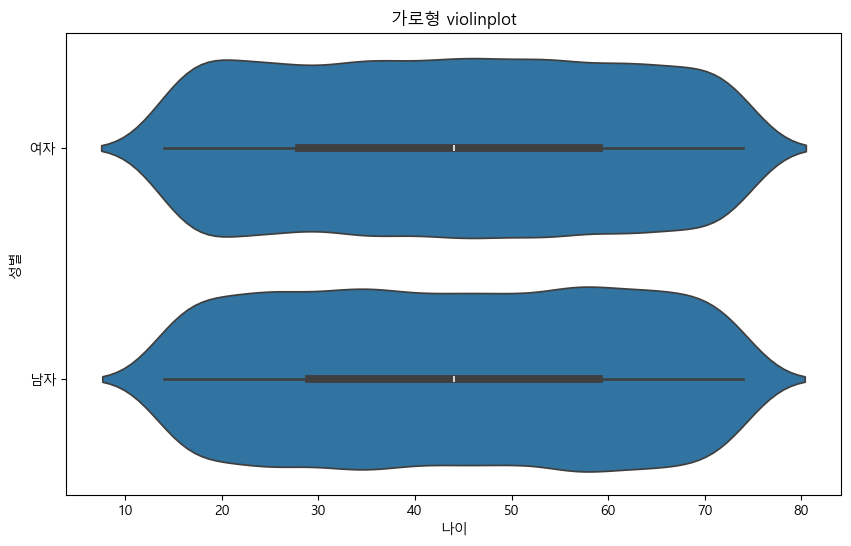

In [87]:
plt.figure(figsize=(10, 6))
plt.title('가로형 violinplot')
sns.violinplot(y='성별', x='나이', data=members)

<Axes: title={'center': 'hue 옵션으로 분포 비교'}, xlabel='종교', ylabel='나이'>

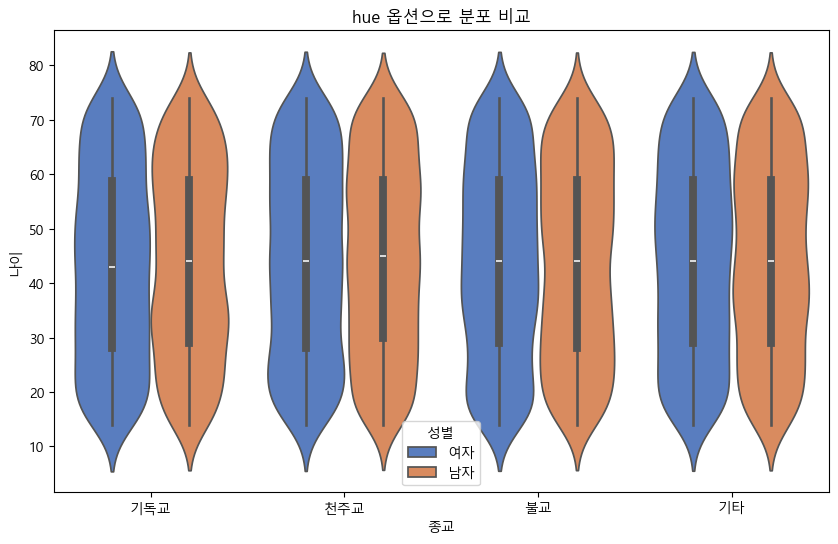

In [88]:
plt.figure(figsize=(10, 6))
plt.title('hue 옵션으로 분포 비교')
sns.violinplot(x='종교', y='나이', hue='성별', data=members, palette="muted")

<h4><font color="green">색인의 생성과 삭제</font></h4>

<h6><font color="BlueViolet">파생 컬럼 만들기</font></h6>

<Figure size 1000x600 with 0 Axes>

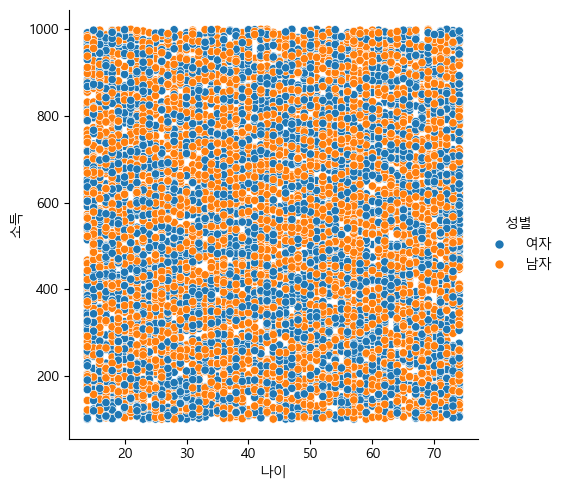

In [89]:
plt.figure(figsize=(10, 6))
sns.relplot(x='나이', y='소득', hue='성별', data=members)

<h6><font color="BlueViolet">색인 삭제하기</font></h6>

In [90]:
members[['소득', '나이']].describe().T

,count,mean,std,min,25%,50%,75%,max
소득,10000.0,546.1170,259.824136,100.0,321.0,546.5,770.0,1000.0
나이,10000.0,43.9583,17.554064,14.0,29.0,44.0,59.0,74.0


Text(0, 0.5, '소득')

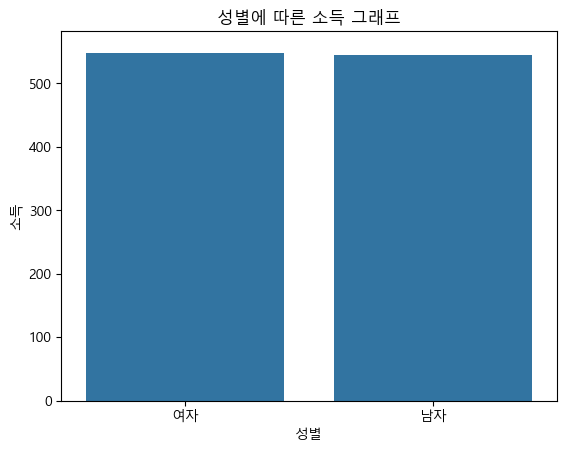

In [91]:
ax = plt.subplots()
# ax = sns.barplot(x='성별', y='소득', data=members, errwidth=0) # errwidth 대신 err_kws 매개 변수 사용 권장
ax = sns.barplot(x='성별', y='소득', data=members, err_kws={'linewidth': 0}) 
ax.set_title('성별에 따른 소득 그래프')
ax.set_xlabel('성별')
ax.set_ylabel('소득')

C:\Users\ugcad\AppData\Local\Temp\ipykernel_8896\371797623.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  ax = sns.barplot(x='성별', y='소득', hue='종교', data=members, errwidth=0)


Text(0, 0.5, '소득')

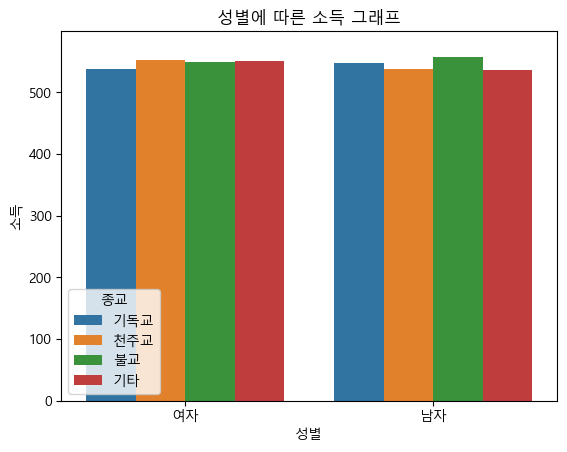

In [92]:
ax = plt.subplots()
ax = sns.barplot(x='성별', y='소득', hue='종교', data=members, errwidth=0)
ax.set_title('성별에 따른 소득 그래프')
ax.set_xlabel('성별')
ax.set_ylabel('소득')

Text(0.5, 0, '소득')

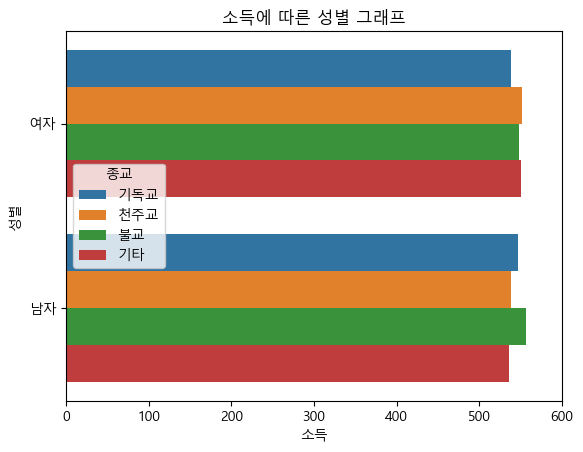

In [93]:
ax = plt.subplots()
ax = sns.barplot(x='소득', y='성별', hue='종교', data=members, err_kws={'linewidth': 0})
ax.set_title('소득에 따른 성별 그래프')
ax.set_ylabel('성별')
ax.set_xlabel('소득')

<h6><font color="BlueViolet">재색인하기</font></h6>

Text(0.5, 1.0, 'members 나이 - 성별/결혼')

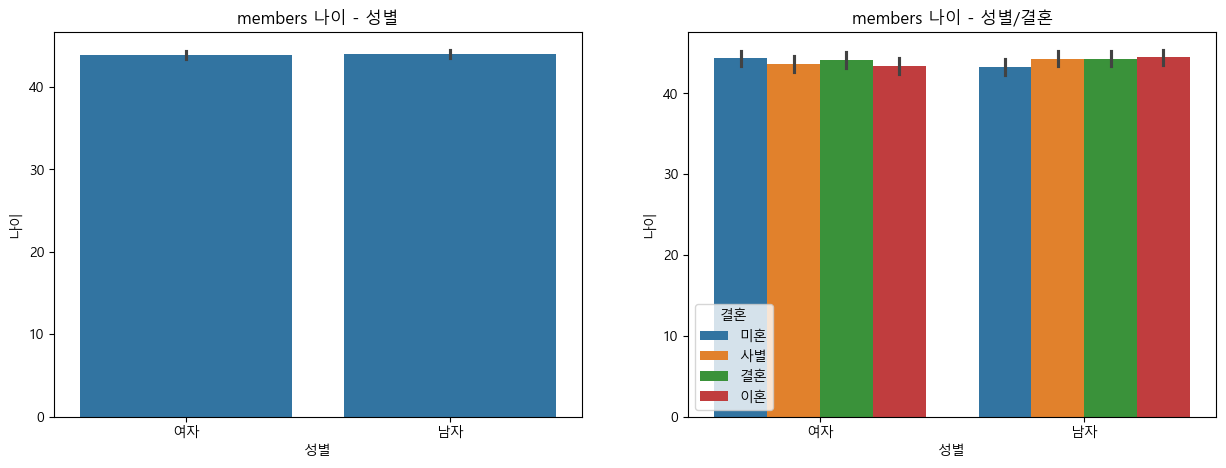

In [94]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글 글꼴 설정

fig = plt.figure(figsize=(15, 5)) # 서브 플롯
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
 
sns.barplot(x='성별', y='나이', data=members, ax=ax1) 

sns.barplot(x='성별', y='나이', hue='결혼', data=members, ax=ax2) 

ax1.set_title('members 나이 - 성별')
ax2.set_title('members 나이 - 성별/결혼')

Text(0, 0.5, '소득')

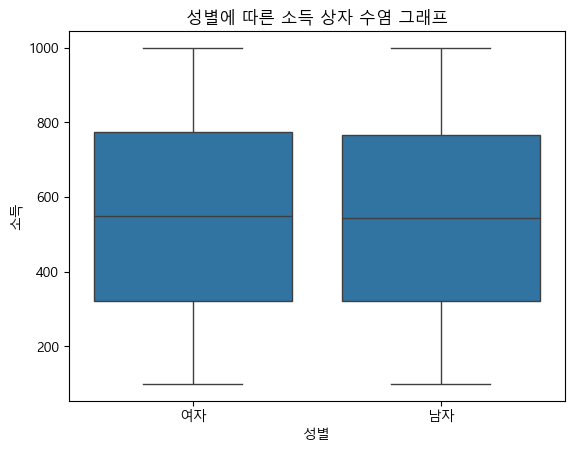

In [95]:
ax = plt.subplots()
ax = sns.boxplot(x='성별', y='소득', data=members)
ax.set_title('성별에 따른 소득 상자 수염 그래프')
ax.set_xlabel('성별')
ax.set_ylabel('소득')

In [96]:
data = members['주소'].str.split(' ')
sido = data.str.get(0)
members['시도'] = sido
piedata = members['시도'].value_counts().head()
piedata.to_frame().T

시도,부산광역시,세종특별자치시,광주광역시,대구광역시,인천광역시
count,650,649,641,638,638


<h6><font color="BlueViolet">파이 그래프 그리기</font></h6>

(-1.0999912794310125,
 1.0999920383575126,
 -1.099999979710871,
 1.099999999033851)

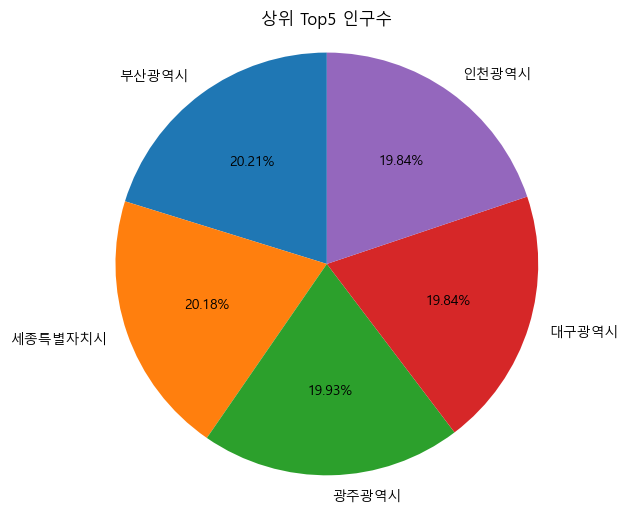

In [97]:
# 파이 그래프 그리기
# sns.set_style('whitegrid')  # 그래프 스타일 설정
plt.figure(figsize=(6, 6))  # 그래프 크기 설정
plt.pie(piedata.values, labels=piedata.index, autopct='%1.2f%%', startangle=90)
plt.title('상위 Top5 인구수')  # 그래프 제목 설정
plt.axis('equal')  # 가로, 세로 비율 동일하게 설정